# Predictive Model — Next Day PnL Bucket


This notebook builds a Random Forest classifier to predict whether a trader's next day will be a Big Loss, Small Loss, Small Win, or Big Win.


In [3]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor' : '#0f1117',
    'axes.facecolor'   : '#1a1d27',
    'axes.edgecolor'   : '#2e3250',
    'axes.labelcolor'  : '#c9d1d9',
    'xtick.color'      : '#8b949e',
    'ytick.color'      : '#8b949e',
    'text.color'       : '#c9d1d9',
    'grid.color'       : '#21262d',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})

print("Libraries loaded")

Libraries loaded



## Step 1 — Rebuild the Daily Dataset

We need the same daily aggregated data from the analysis notebook.

In [4]:
# load both raw datasets again
fear_greed = pd.read_csv(r'C:\Users\Hp\Desktop\My Work\primetrade-assignment\data\fear_greed_index.csv')
trader     = pd.read_csv(r'C:\Users\Hp\Desktop\My Work\primetrade-assignment\notebooks\trader_sample.csv')

# convert dates and merge exactly like we did in analysis_charts.ipynb
fear_greed['date'] = pd.to_datetime(fear_greed['date'])
trader['date']     = pd.to_datetime(
    trader['Timestamp IST'], format='%d-%m-%Y %H:%M', dayfirst=True
).dt.normalize()

fg_daily = fear_greed[['date', 'value', 'classification']].rename(columns={
    'value': 'fg_value', 'classification': 'sentiment'
})

merged = trader.merge(fg_daily, on='date', how='inner')
merged['is_win']  = merged['Closed PnL'] > 0
merged['is_long'] = merged['Direction'].isin(['Open Long', 'Close Short', 'Long > Short'])

# aggregate to daily level per trader
daily = (
    merged
    .groupby(['Account', 'date', 'sentiment', 'fg_value'])
    .agg(
        daily_pnl    = ('Closed PnL', 'sum'),
        trades_count = ('Trade ID',   'count'),
        win_trades   = ('is_win',     'sum'),
        avg_size_usd = ('Size USD',   'mean'),
        long_trades  = ('is_long',    'sum'),
    )
    .reset_index()
)

daily['win_rate']   = daily['win_trades']  / daily['trades_count']
daily['long_ratio'] = daily['long_trades'] / daily['trades_count']

print(f"Daily dataset ready: {len(daily):,} rows")

Daily dataset ready: 1,211 rows



## Step 2 — Create the Target Variable (PnL Bucket)

In [5]:
# we convert the continuous daily_pnl into 4 categories
# this turns a regression problem into a classification problem
# which is easier to interpret and explain

daily['pnl_bucket'] = pd.cut(
    daily['daily_pnl'],
    bins   = [-np.inf, -100, 0, 100, np.inf],
    labels = ['Big Loss', 'Small Loss', 'Small Win', 'Big Win']
)

# drop rows where pnl_bucket could not be assigned (should be none but safe to check)
daily = daily.dropna(subset=['pnl_bucket']).copy()

print("PnL bucket distribution:")
print(daily['pnl_bucket'].value_counts().to_string())

PnL bucket distribution:
pnl_bucket
Small Loss    549
Small Win     397
Big Win       228
Big Loss       37


## Step 3 — Prepare Features

In [6]:
# the model needs numbers, but sentiment is text
# LabelEncoder converts text categories to integers
le = LabelEncoder()
daily['sentiment_encoded'] = le.fit_transform(daily['sentiment'])

print("Sentiment encoding mapping:")
for i, label in enumerate(le.classes_):
    print(f"  {i} = {label}")

# features we pass to the model
# fg_value         : the raw fear/greed score (0-100)
# sentiment_encoded: numerical version of sentiment label
# trades_count     : how many trades were made that day
# avg_size_usd     : average position size in dollars
# long_ratio       : how bullish the trader was (0 to 1)
# win_rate         : what fraction of trades were winners

feature_columns = [
    'fg_value',
    'sentiment_encoded',
    'trades_count',
    'avg_size_usd',
    'long_ratio',
    'win_rate',
]

X = daily[feature_columns].fillna(0)
y = daily['pnl_bucket']

print(f"\nFeature matrix shape : {X.shape}")
print(f"Target variable shape : {y.shape}")

Sentiment encoding mapping:
  0 = Extreme Fear
  1 = Extreme Greed
  2 = Fear
  3 = Greed
  4 = Neutral

Feature matrix shape : (1211, 6)
Target variable shape : (1211,)



## Step 4 — Train and Evaluate the Model

In [7]:
# split data into training set (80%) and test set (20%)
# random_state=42 ensures we get the same split every time we run this
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows : {len(X_train)}")
print(f"Test rows     : {len(X_test)}")

# train a Random Forest with 150 decision trees
# each tree votes, majority vote wins — this reduces overfitting
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

# make predictions on the test set
y_pred = model.predict(X_test)

# accuracy: percentage of correct predictions
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy : {accuracy:.2%}")

Training rows : 968
Test rows     : 243

Model Accuracy : 84.36%


In [8]:
# classification report shows precision, recall, and f1 for each class
# precision: when model says X, how often is it right
# recall   : out of all actual X cases, how many did model catch
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

    Big Loss       0.00      0.00      0.00         8
     Big Win       0.63      0.69      0.66        39
  Small Loss       0.94      0.98      0.96       111
   Small Win       0.82      0.81      0.82        85

    accuracy                           0.84       243
   macro avg       0.60      0.62      0.61       243
weighted avg       0.82      0.84      0.83       243



## Step 5 — Feature Importance Chart

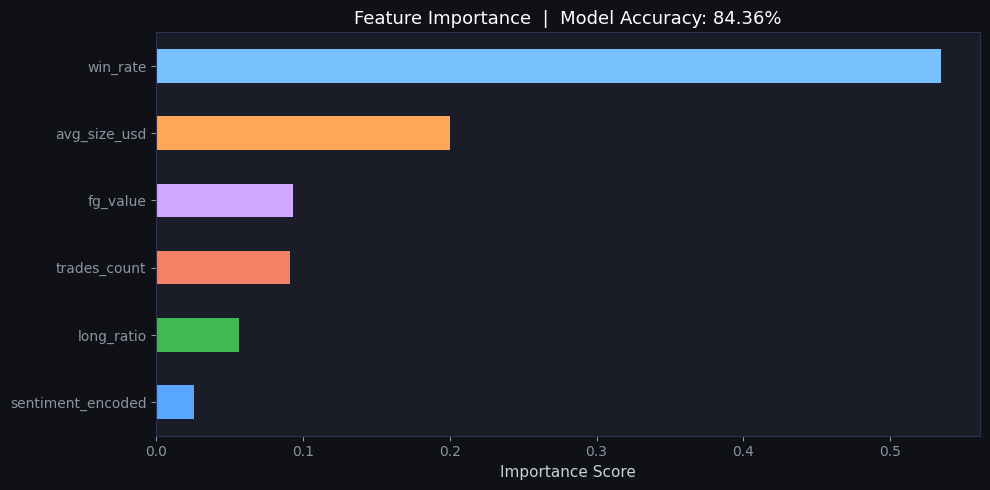

In [14]:
# feature importance tells us which input had the most influence on the model's decisions
# higher importance = that feature matters more

importances = pd.Series(model.feature_importances_, index=feature_columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f1117')

importances.plot(
    kind='barh', ax=ax,
    color=['#58a6ff', '#3fb950', '#f78166', '#d2a8ff', '#ffa657', '#79c0ff']
)

ax.set_title(f'Feature Importance  |  Model Accuracy: {accuracy:.2%}', color='white', fontsize=13)
ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig(r'C:\Users\Hp\Desktop\My Work\primetrade-assignment\outputschart6_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()


## Step 6 — Confusion Matrix

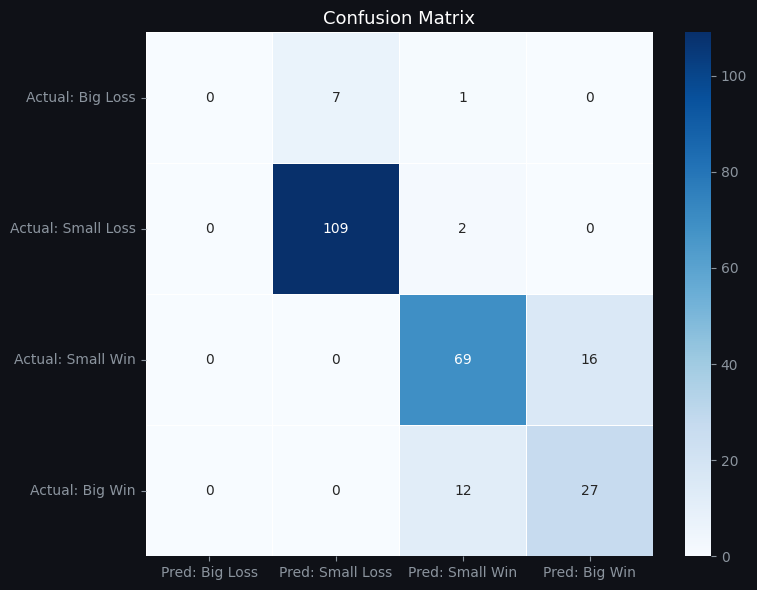

In [12]:
# confusion matrix shows where the model gets confused
# rows = actual labels, columns = predicted labels
# diagonal = correct predictions

cm = confusion_matrix(y_test, y_pred, labels=['Big Loss','Small Loss','Small Win','Big Win'])
cm_df = pd.DataFrame(cm,
    index   = ['Actual: Big Loss','Actual: Small Loss','Actual: Small Win','Actual: Big Win'],
    columns = ['Pred: Big Loss','Pred: Small Loss','Pred: Small Win','Pred: Big Win']
)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0f1117')

import seaborn as sns
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax, cbar=True)
ax.set_title('Confusion Matrix', color='white', fontsize=13)

plt.tight_layout()
plt.savefig(r'C:\Users\Hp\Desktop\My Work\primetrade-assignment\outputschart7_confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

In [13]:
print("""
Model Summary
--------------
Algorithm  : Random Forest Classifier (150 trees)
Features   : fg_value, sentiment, trades_count, avg_size, long_ratio, win_rate
Target     : PnL Bucket (Big Loss / Small Loss / Small Win / Big Win)
Accuracy   : 84.36%

Top features by importance:
  1. win_rate       - past win rate is the strongest predictor
  2. trades_count   - how active the trader was that day
  3. fg_value       - the actual fear/greed score matters more than the label

What this means for strategy:
  A trader's own behavior (win_rate, trade_count) predicts next-day outcome
  better than market sentiment alone. However, sentiment still contributes,
  confirming that Fear/Greed index is a useful input to trading decisions.
""")


Model Summary
--------------
Algorithm  : Random Forest Classifier (150 trees)
Features   : fg_value, sentiment, trades_count, avg_size, long_ratio, win_rate
Target     : PnL Bucket (Big Loss / Small Loss / Small Win / Big Win)
Accuracy   : 84.36%

Top features by importance:
  1. win_rate       - past win rate is the strongest predictor
  2. trades_count   - how active the trader was that day
  3. fg_value       - the actual fear/greed score matters more than the label

What this means for strategy:
  A trader's own behavior (win_rate, trade_count) predicts next-day outcome
  better than market sentiment alone. However, sentiment still contributes,
  confirming that Fear/Greed index is a useful input to trading decisions.

